# Customer Churn Prediction — Telco Dataset

**Business Problem.** As Data Scientists at a telecommunications company, we want to
identify customers who are likely to **churn** (leave the company) so the retention
team can proactively engage them with offers and support.

This notebook delivers the complete workflow:

> Business Problem → Data → Preparation → EDA → Feature Engineering → Model →
> Evaluation → Interpretation → Saved Model → API

- **Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns)
- **Target:** `Churn` (Yes / No)
- **Model:** Decision Tree Classifier
- **Split:** 70% train / 30% test, `random_state = 42`


## 0. Setup & Imports

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

# Make the shared churn_utils module (in the project root) importable and
# resolve project paths regardless of where Jupyter is launched from.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(PROJECT_ROOT, "churn_utils.py")):
    PROJECT_ROOT = os.path.abspath(os.getcwd())
sys.path.insert(0, PROJECT_ROOT)

DATA_PATH = os.path.join(PROJECT_ROOT, "data", "Telco-Customer-Churn.csv")
MODEL_DIR = os.path.join(PROJECT_ROOT, "model")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

import churn_utils as cu
print("churn_utils loaded from:", PROJECT_ROOT)

churn_utils loaded from: /Users/sanjay.yadav01/Documents/Nagarro/NAGP/Assignments/AI&ML/SL/data-science-assignment/data-science-assignment-code


## 1. Data Understanding & Preparation

We load the dataset and run structured checks: types, missing values, duplicates,
numeric vs categorical features, and the target distribution.

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# The customerID is a unique identifier with no predictive value.
print("Unique customerIDs:", df['customerID'].nunique(), "of", len(df))

# TotalCharges is stored as text; it contains blank strings for brand-new
# customers (tenure = 0) who have not been billed yet.
blank_total = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print("Blank TotalCharges values:", blank_total)

Unique customerIDs: 7043 of 7043
Blank TotalCharges values: 11


In [5]:
# Missing-value analysis. TotalCharges is coerced to numeric so the blanks
# surface as NaN (they are otherwise invisible because the column is text).
tmp = df.copy()
tmp['TotalCharges'] = pd.to_numeric(tmp['TotalCharges'].str.strip().replace('', np.nan), errors='coerce')
missing = tmp.isna().sum()
print(missing[missing > 0] if missing.sum() else "No conventional missing values.")
print("\nTotalCharges NaN after coercion:", tmp['TotalCharges'].isna().sum())

TotalCharges    11
dtype: int64

TotalCharges NaN after coercion: 11


In [6]:
# Duplicate analysis
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate rows ignoring customerID:", df.drop(columns=['customerID']).duplicated().sum())
# The 22 rows that match on features but have distinct customerIDs are treated
# as legitimately different customers and are kept.

Exact duplicate rows: 0
Duplicate rows ignoring customerID: 22


In [7]:
# Numerical vs categorical feature identification
numeric_raw = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_raw = [c for c in df.columns
                   if c not in numeric_raw + ['customerID', 'Churn']]
print("Numeric features :", numeric_raw)
print("Categorical feats:", categorical_raw)

Numeric features : ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical feats: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
# Target-variable analysis
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(1)
print(pd.concat([churn_counts, churn_pct], axis=1, keys=['count', 'percent']))
print("\nThe classes are imbalanced (~26.5% churn), which we address with "
      "stratified splitting and a class-weighted model.")

       count  percent
Churn                
No      5174     73.5
Yes     1869     26.5

The classes are imbalanced (~26.5% churn), which we address with stratified splitting and a class-weighted model.


### Preprocessing decisions & how leakage is avoided

- **Drop `customerID`** — pure identifier, no signal.
- **Fix `TotalCharges`** — convert to numeric; the 11 blanks are new customers
  (`tenure = 0`), so `TotalCharges = 0` is the correct interpretation.
- **Encode target** — `Churn` → 1 (Yes) / 0 (No).
- **Encoding & imputation live inside a scikit-learn `Pipeline`** that is fit
  **only on the training split**. One-hot encoder categories and imputer medians
  are learned from training data and then applied to the test set and to any new
  customer, so no information leaks from test/production data into training.
- **Feature engineering is stateless** (`churn_utils.engineer_features`), so it
  can be applied identically to a single incoming API request.

In [9]:
# Target encoding and feature/target separation
y = (df['Churn'] == 'Yes').astype(int)
X_raw = df.drop(columns=['customerID', 'Churn'])
print("Feature matrix:", X_raw.shape, "| Positive (churn) rate:", round(y.mean(), 3))

Feature matrix: (7043, 19) | Positive (churn) rate: 0.265


## 2. Exploratory Data Analysis

At least five visualizations covering the target, customer/service
characteristics, churn vs key attributes, and numeric distributions. Each plot is
followed by a business insight.

In [10]:
# EDA works on a cleaned + engineered copy so numeric fields behave correctly.
eda = cu.engineer_features(X_raw.copy())
eda['Churn'] = df['Churn'].values

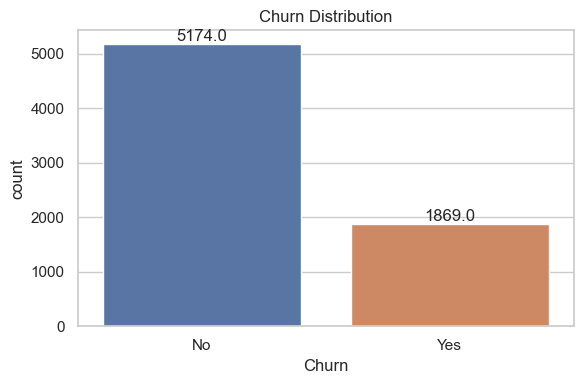

In [11]:
# (1) Churn distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=eda, x='Churn', palette=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title('Churn Distribution')
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '01_churn_distribution.png'), dpi=120)
plt.show()

**Insight:** About 1 in 4 customers churn. This is a sizeable, addressable revenue loss, and the imbalance means accuracy alone is a misleading metric.

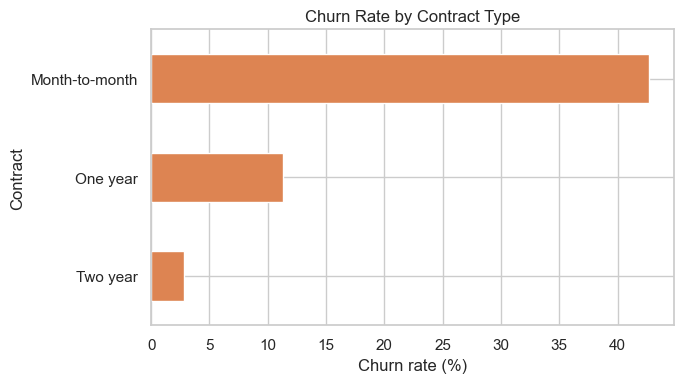

In [12]:
# (2) Churn rate by Contract type
fig, ax = plt.subplots(figsize=(7, 4))
(eda.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean())
    .sort_values().mul(100)).plot(kind='barh', color='#DD8452', ax=ax)
ax.set_title('Churn Rate by Contract Type'); ax.set_xlabel('Churn rate (%)')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '02_churn_by_contract.png'), dpi=120)
plt.show()

**Insight:** Month-to-month customers churn dramatically more than those on one/two-year contracts. Encouraging longer contracts is a strong retention lever.

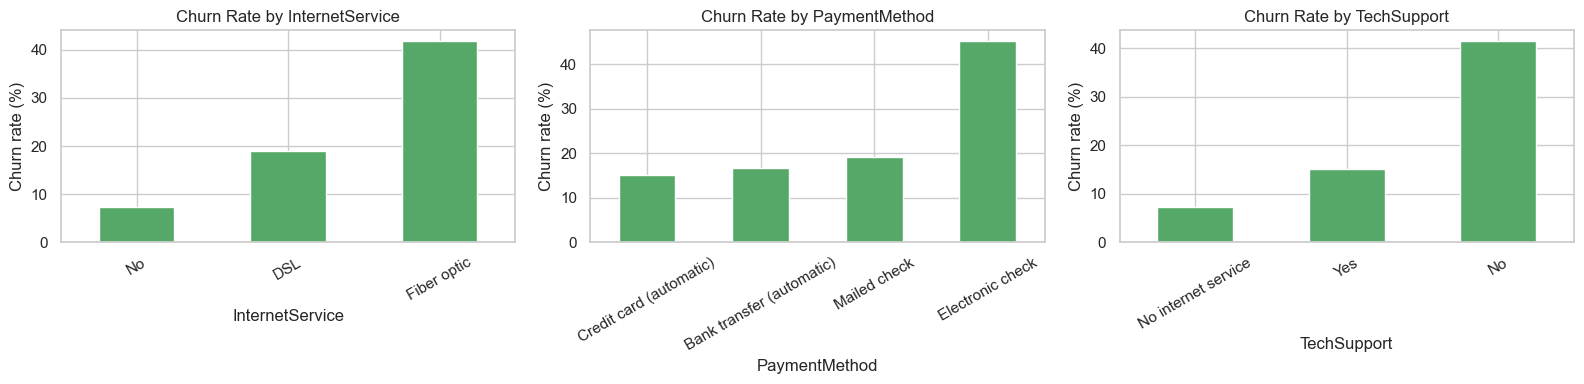

In [13]:
# (3) Churn by key services (InternetService, PaymentMethod, TechSupport)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['InternetService', 'PaymentMethod', 'TechSupport']):
    rate = eda.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean()).mul(100)
    rate.sort_values().plot(kind='bar', color='#55A868', ax=ax)
    ax.set_title(f'Churn Rate by {col}'); ax.set_ylabel('Churn rate (%)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '03_churn_by_services.png'), dpi=120)
plt.show()

**Insight:** Fiber-optic users, customers paying by electronic check, and those **without** tech support churn the most — these segments should be prioritized for proactive outreach.

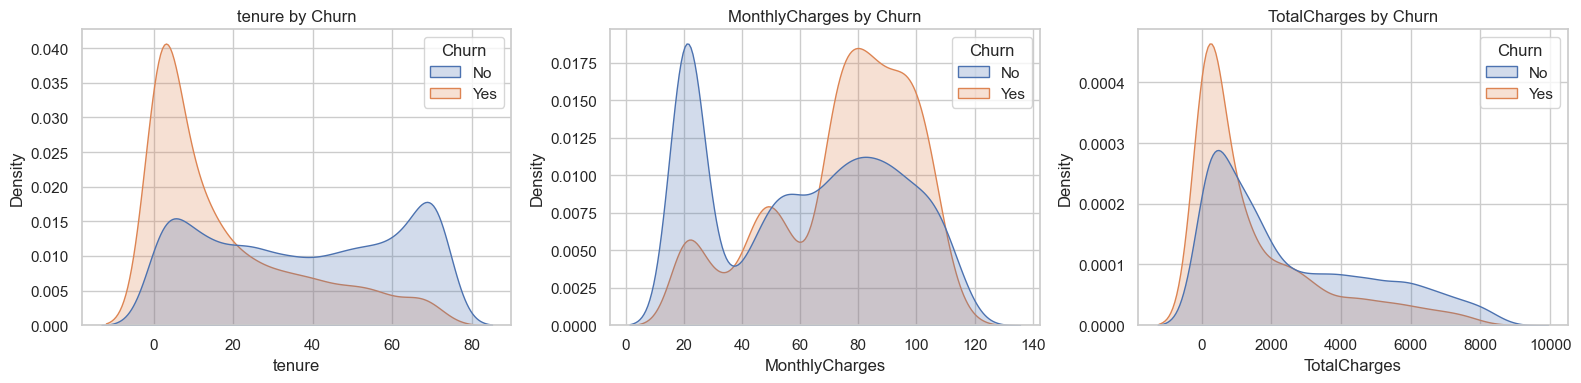

In [14]:
# (4) Numeric distributions by churn
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=eda, x=col, hue='Churn', fill=True, common_norm=False, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '04_numeric_by_churn.png'), dpi=120)
plt.show()

**Insight:** Churners are concentrated at **low tenure** and **high monthly charges**. The first months of a high-bill customer's lifecycle are the riskiest window.

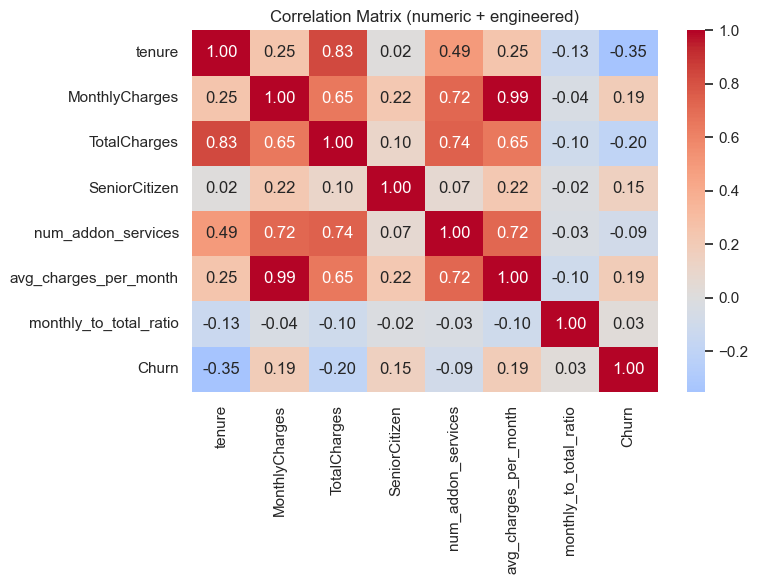

In [15]:
# (5) Correlation heatmap of numeric + engineered features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
            'num_addon_services', 'avg_charges_per_month', 'monthly_to_total_ratio']
corr = eda[num_cols].assign(Churn=(eda['Churn'] == 'Yes').astype(int)).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix (numeric + engineered)')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '05_correlation_heatmap.png'), dpi=120)
plt.show()

**Insight:** `tenure` and `TotalCharges` are negatively correlated with churn, while `MonthlyCharges` and `monthly_to_total_ratio` are positively correlated — confirming that new, high-bill customers are the highest risk.

## 3. Feature Engineering

Engineered features are defined once in `churn_utils.engineer_features` so the API
applies exactly the same logic. Four features are created:

| Feature | How it is created | Why it may help |
|---|---|---|
| `tenure_group` | Bucket `tenure` into 0-12, 13-24, 25-48, 49-60, 61-72 months | Churn risk is highly non-linear and concentrated in the first year; buckets expose this cleanly. |
| `num_addon_services` | Count of the 6 add-on services set to "Yes" | More services = higher stickiness/engagement = lower churn. |
| `avg_charges_per_month` | `TotalCharges / tenure` | Separates long-term high-value customers from new high-bill ones. |
| `monthly_to_total_ratio` | `MonthlyCharges / (TotalCharges + 1)` | Proxy for how "new" the spend is; a high ratio flags short-tenure risk. |


In [16]:
X_eng = cu.engineer_features(X_raw.copy())
engineered_cols = ['tenure_group', 'num_addon_services', 'avg_charges_per_month', 'monthly_to_total_ratio']
X_eng[engineered_cols].head()

,tenure_group,num_addon_services,avg_charges_per_month,monthly_to_total_ratio
0,0-12,1,29.850000,0.967585
1,25-48,2,55.573529,0.030124
2,0-12,2,54.075000,0.493358
3,25-48,3,40.905556,0.022967
4,0-12,0,75.825000,0.463151


In [17]:
# Keep only the columns the model consumes.
X = X_eng[cu.MODEL_FEATURES].copy()
print("Model feature count:", X.shape[1])
print("Numeric     :", cu.NUMERIC_FEATURES)
print("Categorical :", cu.CATEGORICAL_FEATURES)

Model feature count: 23
Numeric     : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_addon_services', 'avg_charges_per_month', 'monthly_to_total_ratio']
Categorical : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


## 4. Model Development

We build a Decision Tree Classifier inside a `Pipeline` (feature engineering →
preprocessing → tree) and compare **two configurations**.

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score)

# 70:30 stratified split on the RAW features so the whole pipeline (including
# feature engineering) is learned only from the training data.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train_raw.shape, "| Test:", X_test_raw.shape)

Train: (4930, 19) | Test: (2113, 19)


In [19]:
def build_preprocessor():
    numeric = Pipeline([('impute', SimpleImputer(strategy='median'))])
    categorical = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer([
        ('num', numeric, cu.NUMERIC_FEATURES),
        ('cat', categorical, cu.CATEGORICAL_FEATURES),
    ])

def make_pipeline(tree):
    # FunctionTransformer runs the SAME engineer_features used at serving time,
    # so the persisted pipeline accepts RAW customer data end-to-end.
    return Pipeline([
        ('engineer', FunctionTransformer(cu.engineer_features, validate=False)),
        ('prep', build_preprocessor()),
        ('clf', tree),
    ])

In [20]:
# --- Model A: baseline shallow tree (interpretable, low variance) ---
model_a = make_pipeline(DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))
model_a.fit(X_train_raw, y_train)

# --- Model B: class-weighted tree tuned with GridSearchCV (optimising recall
#     of the churn class, which matters most for retention) ---
param_grid = {
    'clf__max_depth': [4, 6, 8, 10, None],
    'clf__min_samples_leaf': [1, 10, 20, 50],
    'clf__criterion': ['gini', 'entropy'],
}
grid = GridSearchCV(
    make_pipeline(DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_raw, y_train)
model_b = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_leaf': 50}


In [21]:
def evaluate(model, name):
    pred = model.predict(X_test_raw)
    proba = model.predict_proba(X_test_raw)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    }

comparison = pd.DataFrame([
    evaluate(model_a, 'A: baseline tree (max_depth=4)'),
    evaluate(model_b, 'B: tuned, class-weighted tree'),
]).set_index('model').round(3)
comparison

,accuracy,precision,recall,f1,roc_auc
model,,,,,
A: baseline tree (max_depth=4),0.788,0.641,0.453,0.531,0.825
"B: tuned, class-weighted tree",0.735,0.500,0.777,0.609,0.833


### Model selection & justification

**Model B (the tuned, class-weighted tree)** is selected as the final model.
Although the baseline can show marginally higher raw accuracy, Model B delivers a
substantially higher **recall** on the churn class. In a retention context, the
cost of *missing* a customer who will churn (lost lifetime value) far outweighs
the cost of a *false alarm* (a low-cost retention offer). Model B therefore aligns
best with the business objective, and `class_weight='balanced'` directly addresses
the class imbalance.

In [22]:
final_model = model_b

## 5. Model Evaluation

We report Accuracy, Precision, Recall, F1 and the Confusion Matrix for the final
model, then interpret them for the business.

In [23]:
y_pred = final_model.predict(X_test_raw)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

final_metrics = evaluate(final_model, 'final')
print({k: round(v, 3) for k, v in final_metrics.items() if k != 'model'})

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1552
       Churn       0.50      0.78      0.61       561

    accuracy                           0.73      2113
   macro avg       0.70      0.75      0.70      2113
weighted avg       0.79      0.73      0.75      2113

{'accuracy': 0.735, 'precision': 0.5, 'recall': 0.777, 'f1': 0.609, 'roc_auc': np.float64(0.833)}


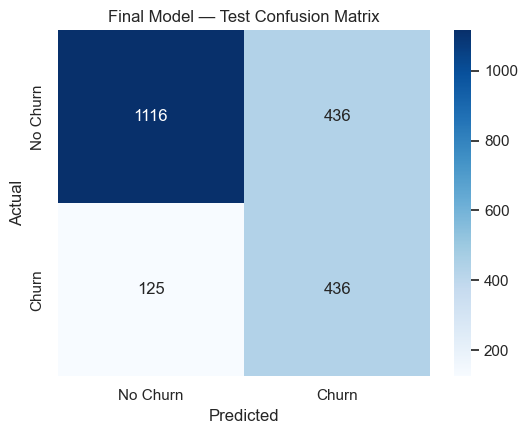

In [24]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Final Model — Test Confusion Matrix')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '06_confusion_matrix.png'), dpi=120)
plt.show()

### Business interpretation — Precision vs Recall

**We prioritise Recall.** For a telecom retention program:

- A **false negative** (predicting a churner will stay) means we lose the customer
  and their future revenue — expensive and unrecoverable.
- A **false positive** (predicting a loyal customer will churn) only costs a small
  retention incentive sent to someone who was staying anyway — cheap.

Because missing a real churner is far costlier than a false alarm, **Recall on the
churn class is the priority metric**, with F1 as a balancing guardrail so precision
does not collapse. This is exactly why we chose the class-weighted model.

## 6. Model Interpretation

We inspect feature importance and visualize the tree to explain what drives
predictions.

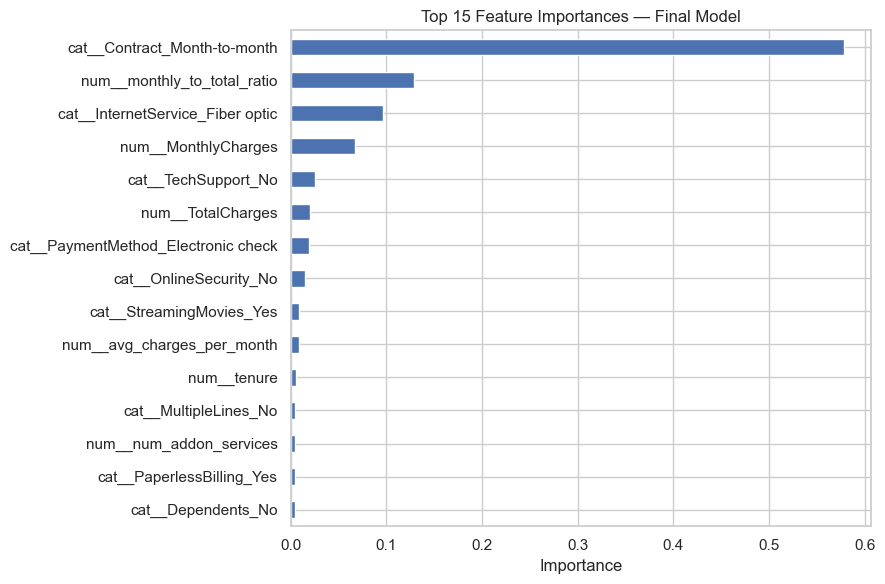

cat__Contract_Month-to-month           0.578076
num__monthly_to_total_ratio            0.128755
cat__InternetService_Fiber optic       0.096271
num__MonthlyCharges                    0.066779
cat__TechSupport_No                    0.025150
num__TotalCharges                      0.019664
cat__PaymentMethod_Electronic check    0.018628
cat__OnlineSecurity_No                 0.014961
cat__StreamingMovies_Yes               0.008942
num__avg_charges_per_month             0.008335
dtype: float64

In [25]:
# Map one-hot feature names back to importances from the fitted pipeline.
prep = final_model.named_steps['prep']
feat_names = prep.get_feature_names_out()
importances = final_model.named_steps['clf'].feature_importances_
imp = (pd.Series(importances, index=feat_names)
       .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
imp.iloc[::-1].plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_title('Top 15 Feature Importances — Final Model'); ax.set_xlabel('Importance')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '07_feature_importance.png'), dpi=120)
plt.show()
imp.head(10)

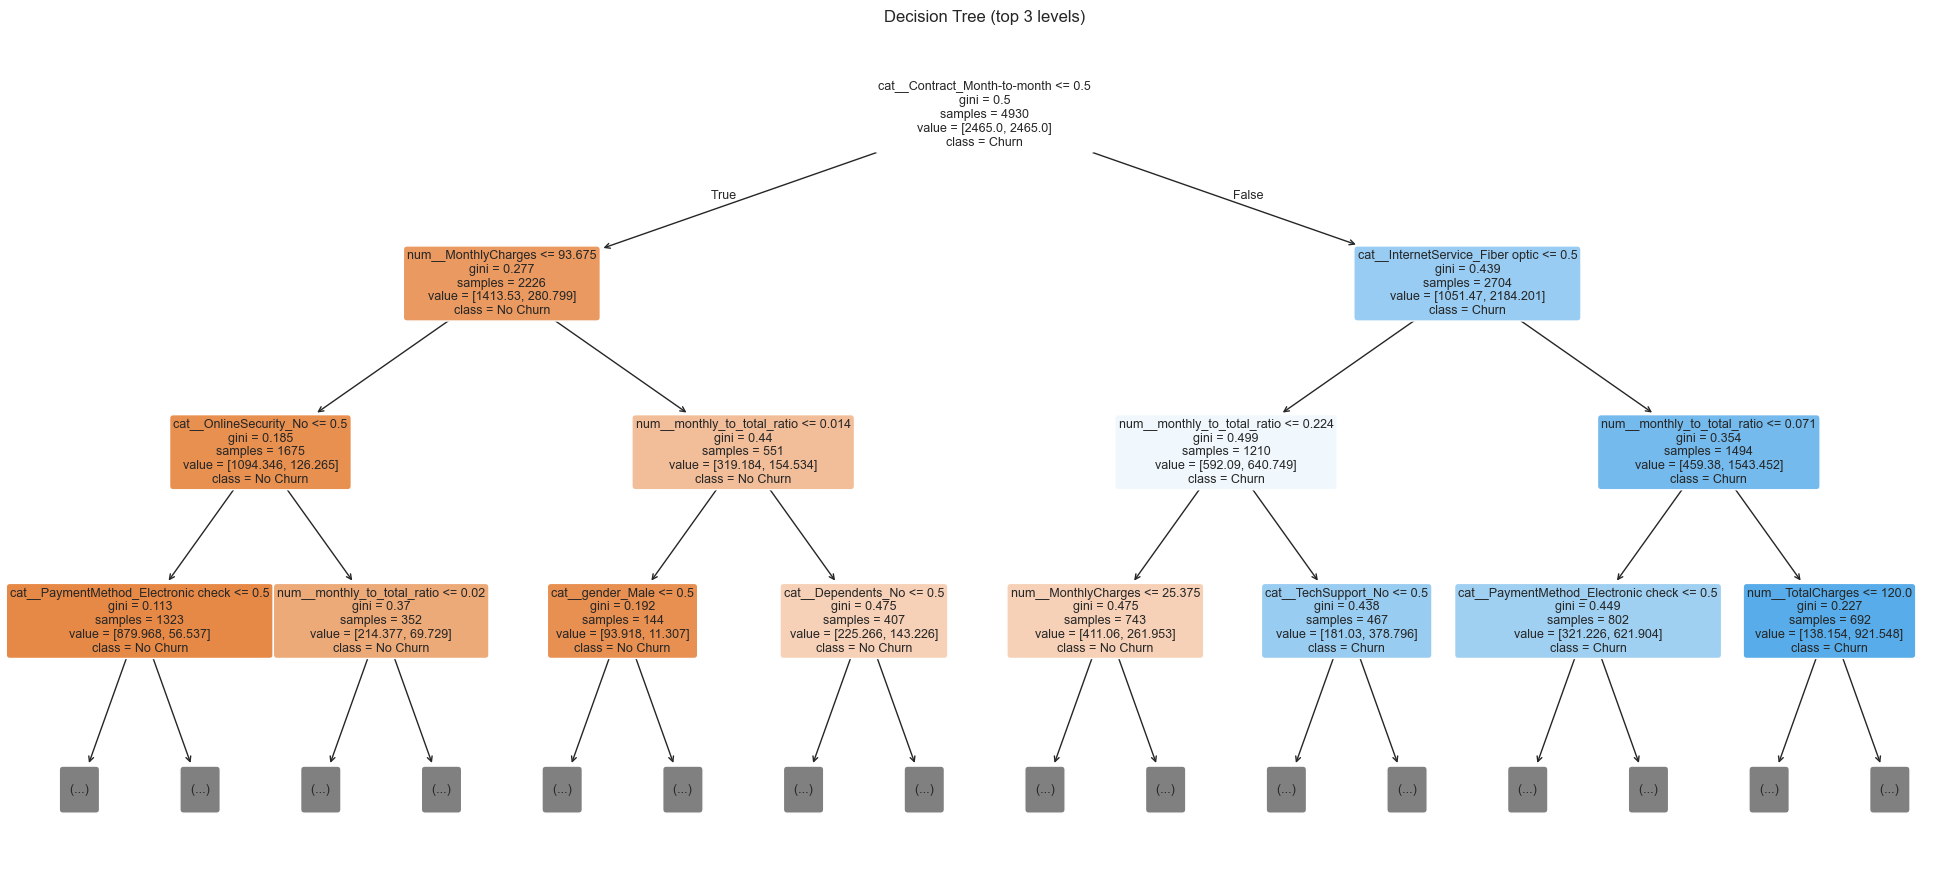

In [26]:
# Decision tree visualization (top levels for readability)
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(final_model.named_steps['clf'], max_depth=3, feature_names=feat_names,
          class_names=['No Churn', 'Churn'], filled=True, rounded=True,
          fontsize=9, ax=ax)
ax.set_title('Decision Tree (top 3 levels)')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '08_decision_tree.png'), dpi=120)
plt.show()

### Key findings

- **Contract type** (month-to-month) and **tenure / tenure_group** are the
  dominant churn drivers — early-life month-to-month customers are the highest risk.
- **Charges** (`MonthlyCharges`, `avg_charges_per_month`) and **internet/payment**
  attributes add further signal: high-bill fiber and electronic-check customers churn more.
- The engineered features (`tenure_group`, `num_addon_services`) surface among the
  top splits, confirming they add value.

**Actionable takeaway:** target month-to-month, low-tenure, high-charge customers —
especially those with few add-on services and no tech support — with contract
incentives and support outreach.

## 7. Model Saving & API

We persist the full pipeline (feature engineering + preprocessing + model) so the
Flask API can load it and score raw customer JSON directly.

In [27]:
import joblib

artifact = {
    'pipeline': final_model,
    'raw_feature_columns': cu.RAW_FEATURE_COLUMNS,
    'model_features': cu.MODEL_FEATURES,
    'metrics': {k: float(v) for k, v in final_metrics.items() if k != 'model'},
    'threshold': 0.5,
}
model_path = os.path.join(MODEL_DIR, 'churn_model.pkl')
joblib.dump(artifact, model_path)
print('Saved model to:', model_path)

Saved model to: /Users/sanjay.yadav01/Documents/Nagarro/NAGP/Assignments/AI&ML/SL/data-science-assignment/data-science-assignment-code/model/churn_model.pkl


In [28]:
# Sanity check: reload and predict on one raw customer, and write sample_request.json
import json

loaded = joblib.load(model_path)
sample = X_test_raw.iloc[[0]].copy()
sample_dict = sample.iloc[0].to_dict()
# Cast numpy types to native Python for clean JSON.
sample_dict = {k: (int(v) if isinstance(v, (np.integer,)) else
                   float(v) if isinstance(v, (np.floating,)) else v)
               for k, v in sample_dict.items()}

proba = float(loaded['pipeline'].predict_proba(sample)[0, 1])
pred = 'Yes' if proba >= loaded['threshold'] else 'No'
print('Prediction:', pred, '| churn_probability:', round(proba, 4))

with open(os.path.join(PROJECT_ROOT, 'sample_request.json'), 'w') as f:
    json.dump(sample_dict, f, indent=2)
print('Wrote sample_request.json')
sample_dict

Prediction: Yes | churn_probability: 0.6359
Wrote sample_request.json


{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'No',
 'Dependents': 'No',
 'tenure': 18,
 'PhoneService': 'Yes',
 'MultipleLines': 'No',
 'InternetService': 'Fiber optic',
 'OnlineSecurity': 'Yes',
 'OnlineBackup': 'No',
 'DeviceProtection': 'No',
 'TechSupport': 'No',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'Yes',
 'Contract': 'Month-to-month',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Electronic check',
 'MonthlyCharges': 96.05,
 'TotalCharges': '1740.7'}

### Using the API

Start the server and send a request (see `README.md` and `sample_request.json`):

```bash
python app.py
curl -X POST http://127.0.0.1:5000/predict \
     -H "Content-Type: application/json" \
     -d @sample_request.json
```

Example response:

```json
{ "prediction": "Yes", "churn_probability": 0.82 }
```

**Summary.** We completed the full workflow — data preparation, EDA, feature
engineering, a compared/selected Decision Tree, business-oriented evaluation,
interpretation, a persisted pipeline, and a REST API — for proactive churn
retention.